In [2]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import download_prices, get_log_prices
from src.signals_rolling import (
    rolling_hedge_ratio,
    compute_rolling_spread,
    compute_rolling_zscore,
    generate_positions,
)
from src.backtest import run_backtest
from src.metrics import summarize_results

## Data Loading

In [3]:
tickers = ["KO", "PEP"]
start = "2015-01-01"
end = "2022-12-31"

prices = download_prices(tickers, start=start, end=end)
lp = get_log_prices(prices)

prices.head()


[*********************100%***********************]  2 of 2 completed


Ticker,KO,PEP
Date,,
2015-01-02,29.390265,66.582954
2015-01-05,29.390265,66.082359
2015-01-06,29.613445,65.581779
2015-01-07,29.983095,67.499466
2015-01-08,30.345753,68.726227


## Backtesting the Strategy

In [4]:
window = 60
entry = 2.0
exit = 0.5
tc_rate = 0.0002 # costs may be lower as PEP/KO are high liquidity stocks, so trading costs may be lesser
slippage_rate = 0.0005

In [5]:
hedge_ratios = rolling_hedge_ratio(lp, window=window)

spread = compute_rolling_spread(lp, hedge_ratios)

zscore = compute_rolling_zscore(spread, window=window)

positions = generate_positions(zscore, entry=entry, exit=exit)

In [6]:
results = run_backtest(
    prices=prices,
    positions=positions,
    hedge_ratios=hedge_ratios,
    tc_rate=tc_rate,
    slippage_rate=slippage_rate,
)

results.tail()

,positions,daily_pnl,cum_pnl,trading_costs,y_units,x_units
Date,,,,,,
2022-12-23,1,0.750473,-16.449750,0.000421,1,-0.656122
2022-12-27,1,0.488310,-15.961440,0.000553,1,-0.642467
2022-12-28,1,-0.802722,-16.764162,0.000844,1,-0.621425
2022-12-29,1,-0.009327,-16.773489,0.000692,1,-0.604284
2022-12-30,1,-0.987961,-17.761450,0.000607,1,-0.589155


In [7]:
summary = summarize_results(results)
summary

{'total_pnl': -17.761449821534494,
 'sharpe': -0.2086122987927716,
 'max_drawdown': -35.24654442795082,
 'num_trades': 87}

In [8]:
# Cost drag calculation
total_costs = results['trading_costs'].sum()
gross_pnl   = (results['daily_pnl'] + results['trading_costs']).sum()
net_pnl     = results['daily_pnl'].sum()
cost_drag   = total_costs / abs(gross_pnl) * 100 if gross_pnl != 0 else float('nan')

print(summary)
print(f'\nGross PnL: ${gross_pnl:.2f} | Total costs: ${total_costs:.2f} | Net PnL: ${net_pnl:.2f}')
print(f'Cost drag: {cost_drag:.1f}% of gross PnL')

{'total_pnl': -17.761449821534494, 'sharpe': -0.2086122987927716, 'max_drawdown': -35.24654442795082, 'num_trades': 87}

Gross PnL: $-9.15 | Total costs: $8.61 | Net PnL: $-17.76
Cost drag: 94.1% of gross PnL


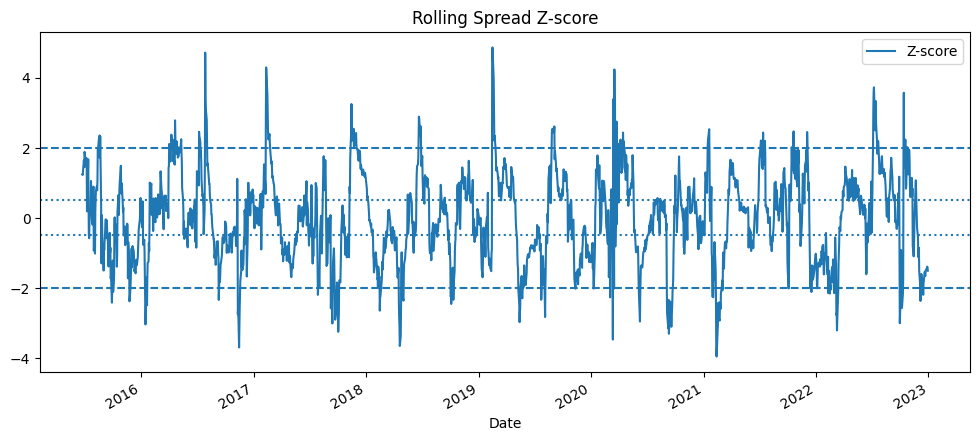

In [9]:
plt.figure(figsize=(12, 5))
zscore.plot(label="Z-score")
plt.axhline(entry, linestyle="--")
plt.axhline(-entry, linestyle="--")
plt.axhline(exit, linestyle=":")
plt.axhline(-exit, linestyle=":")
plt.title("Rolling Spread Z-score")
plt.legend()
plt.show()

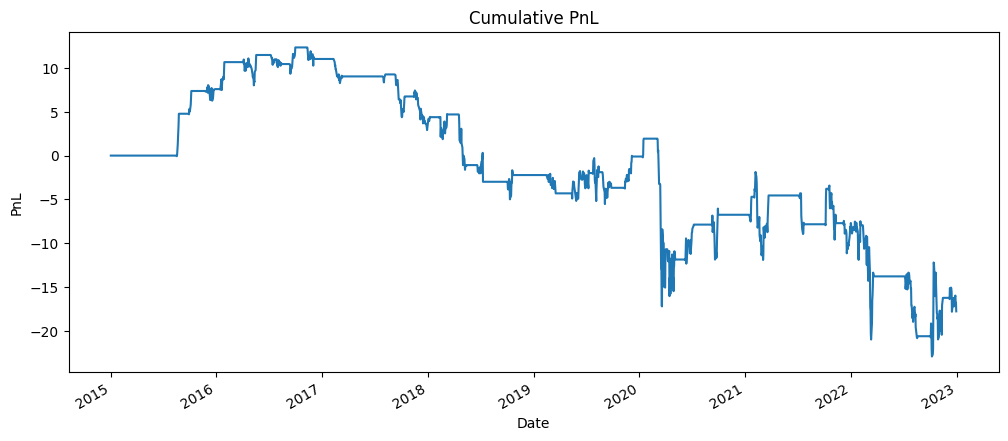

In [10]:
plt.figure(figsize=(12, 5))
results["cum_pnl"].plot()
plt.title("Cumulative PnL")
plt.ylabel("PnL")
plt.show()

## Grid search for better hyperparameters 

In [11]:
experiments = []

for window in [30, 60, 90, 120]:
    for entry in [1.5, 2.0, 2.5]:
        hedge_ratios = rolling_hedge_ratio(lp, window=window)
        spread = compute_rolling_spread(lp, hedge_ratios)
        zscore = compute_rolling_zscore(spread, window=window)
        positions = generate_positions(zscore, entry=entry, exit=0.5)

        results = run_backtest(
            prices=prices,
            positions=positions,
            hedge_ratios=hedge_ratios,
            tc_rate=tc_rate,
            slippage_rate=slippage_rate,
        )

        summary = summarize_results(results)
        summary["window"] = window
        summary["entry"] = entry
        summary["exit"] = 0.5

        experiments.append(summary)

experiment_results = pd.DataFrame(experiments)
experiment_results.sort_values("sharpe", ascending=False)

,total_pnl,sharpe,max_drawdown,num_trades,window,entry,exit
5,-6.091522,-0.092228,-22.435758,50,60,2.5,0.5
4,-17.761450,-0.208612,-35.246544,87,60,2.0,0.5
3,-25.511653,-0.274001,-39.669446,119,60,1.5,0.5
2,-17.369338,-0.309022,-28.827915,74,30,2.5,0.5
6,-30.871354,-0.330260,-44.196749,91,90,1.5,0.5
11,-23.897208,-0.364076,-41.915304,34,120,2.5,0.5
1,-26.916835,-0.385055,-42.036808,140,30,2.0,0.5
10,-31.300314,-0.400066,-42.812519,50,120,2.0,0.5
9,-41.942055,-0.465258,-61.284345,72,120,1.5,0.5
0,-45.736284,-0.512182,-69.422101,232,30,1.5,0.5


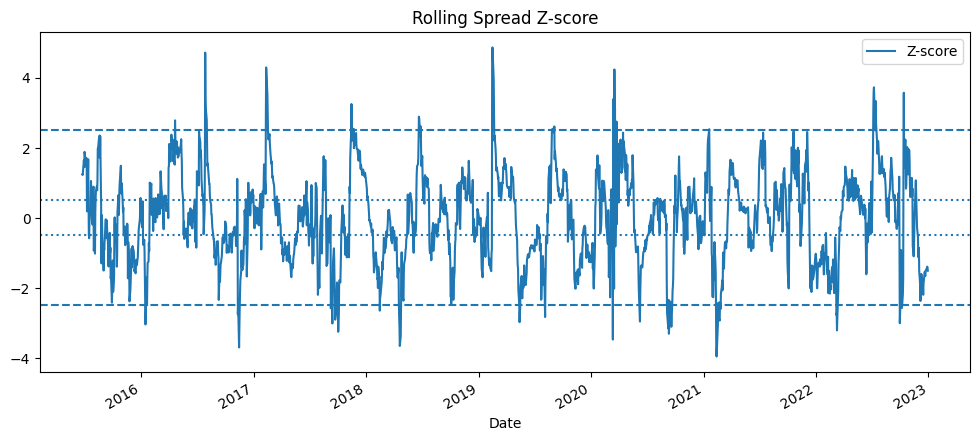

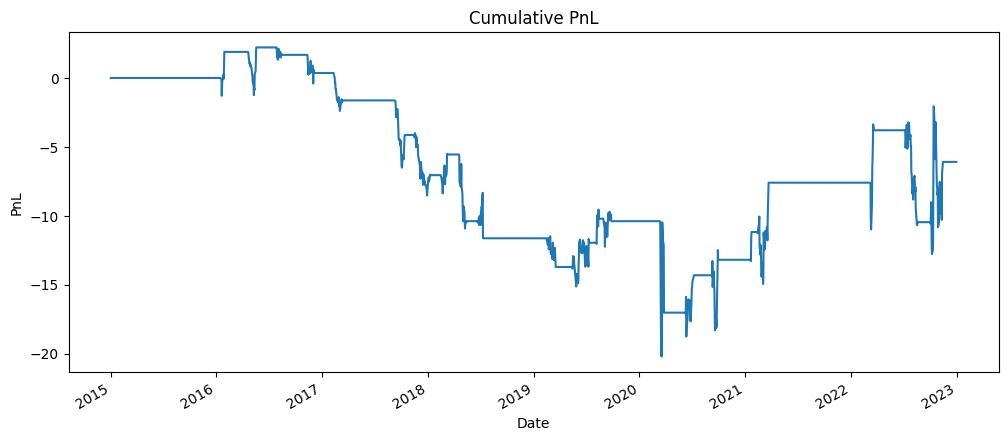

{'total_pnl': -6.091522497603603,
 'sharpe': -0.09222774654659376,
 'max_drawdown': -22.43575767522365,
 'num_trades': 50}

In [15]:
window = 60
entry = 2.5
exit = 0.5
tc_rate = 0.0002
slippage_rate = 0.0005

hedge_ratios = rolling_hedge_ratio(lp, window=window)
spread = compute_rolling_spread(lp, hedge_ratios)
zscore = compute_rolling_zscore(spread, window=window)
positions = generate_positions(zscore, entry=entry, exit=exit)

results = run_backtest(
    prices=prices, positions=positions,
    hedge_ratios=hedge_ratios, tc_rate=tc_rate, slippage_rate=slippage_rate,
)

plt.figure(figsize=(12, 5))
zscore.plot(label="Z-score")
plt.axhline(entry, linestyle="--")
plt.axhline(-entry, linestyle="--")
plt.axhline(exit, linestyle=":")
plt.axhline(-exit, linestyle=":")
plt.title("Rolling Spread Z-score")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
results["cum_pnl"].plot()
plt.title("Cumulative PnL")
plt.ylabel("PnL")
plt.show()

summary = summarize_results(results)
summary
